In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Imports

import pandas as pd
import numpy as np
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve, auc


In [ ]:
# LOAD DATA

data = pd.read_csv("/content/drive/MyDrive/Methane_Monitoring_Paper/EU_Data/cleaned_methane_data.csv")

# sort for temporal consistency (important for spatiotemporal ML)
data = data.sort_values(["hex_id", "year", "month"])


# TARGET variable

data["target"] = (data["CH4_zscore"] > 2).astype(int)

print("Hotspot ratio:", data["target"].mean())
print(data["target"].value_counts())


# TEMPORAL ENCODING (IMPORTANT)

data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)


Hotspot ratio: 0.005476774042950513
target
0    4090116
1      22524
Name: count, dtype: int64


In [ ]:
# SPATIOTEMPORAL SPLIT (NO LEAKAGE)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(data, groups=data["hex_id"]))

train_df = data.iloc[train_idx].copy()
test_df  = data.iloc[test_idx].copy()

y_train = train_df["target"]
y_test  = test_df["target"]

In [ ]:
# IMBALANCE HANDLING

pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / max(pos, 1)

print("Scale pos weight:", scale_pos_weight)


# FEATURE SETS (REALISTIC + CLEAN)


# Base environmental + spatial predictors
base_features = [
    "NDVI","NDWI","NDMI","NDBI","BSI",
    "wind_speed","wind_direction",
    "elevation","slope","infra_distance",
    "month_sin","month_cos"
]

# MODEL A: FULL (includes CH4 observational info)
features_A = base_features + [
    "CH4_mean",
    "CH4_std",
    "CH4_zscore",
    "CH4_persistence"
]

# MODEL B: STRICT (no methane signal leakage)
features_B = base_features


Scale pos weight: 182.88329979879276


In [ ]:
# DATA PREP

X_train_A = train_df[features_A].fillna(0)
X_test_A  = test_df[features_A].fillna(0)

X_train_B = train_df[features_B].fillna(0)
X_test_B  = test_df[features_B].fillna(0)

In [ ]:
# MODEL CONFIG (STABLE FOR IMBALANCED DATA)

def train_lgb(X_train, y_train, X_test, y_test):

    model = lgb.LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="aucpr",
        callbacks=[
            lgb.early_stopping(150),
            lgb.log_evaluation(100)
        ]
    )

    probs = model.predict_proba(X_test)[:, 1]

    roc = roc_auc_score(y_test, probs)
    pr  = average_precision_score(y_test, probs)

    # threshold tuning
    thresholds = np.linspace(0.1, 0.99, 50)
    best_f1, best_t = 0, 0

    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1 = (2 * ((preds & y_test).sum())) / max((preds.sum() + y_test.sum()), 1)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    final_preds = (probs >= best_t).astype(int)

    report = classification_report(y_test, final_preds)

    return model, roc, pr, best_t, best_f1, report



# MODEL A (FULL)

model_A, roc_A, pr_A, t_A, f1_A, rep_A = train_lgb(
    X_train_A, y_train, X_test_A, y_test
)

print("\n================ MODEL A (FULL) ================")
print("ROC-AUC:", roc_A)
print("PR-AUC:", pr_A)
print("Best threshold:", t_A)
print("Best F1:", f1_A)
print(rep_A)


#  MODEL B (STRICT)

model_B, roc_B, pr_B, t_B, f1_B, rep_B = train_lgb(
    X_train_B, y_train, X_test_B, y_test
)

print("\n=== MODEL B (STRICT) =====")
print("ROC-AUC:", roc_B)
print("PR-AUC:", pr_B)
print("Best threshold:", t_B)
print("Best F1:", f1_B)
print(rep_B)


# FINAL ABLATION SUMMARY

results = pd.DataFrame({
    "Model": ["Full (A)", "Strict (B)"],
    "ROC-AUC": [roc_A, roc_B],
    "PR-AUC": [pr_A, pr_B],
    "F1": [f1_A, f1_B]
})

print("\n===== ABLATION RESULTS =====")
print(results)

[LightGBM] [Info] Number of positive: 17892, number of negative: 3272148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.136384 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3592
[LightGBM] [Info] Number of data points in the train set: 3290040, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005438 -> initscore=-5.208848
[LightGBM] [Info] Start training from score -5.208848
Training until validation scores don't improve for 150 rounds
[100]	valid_0's binary_logloss: 0.00146802
[200]	valid_0's binary_logloss: 0.00140496
Early stopping, best iteration is:
[148]	valid_0's binary_logloss: 0.00128846

================ MODEL A (FULL) ================
ROC-AUC: 0.9999545429324893
PR-AUC: 0.9904724322500699
Best threshold: 0.1
Best F1: 0.9817719372615515
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    817968
           1  

In [ ]:
probs_A = model_A.predict_proba(X_test_A)[:,1]
probs_B = model_B.predict_proba(X_test_B)[:,1]
y_test = test_df["target"]

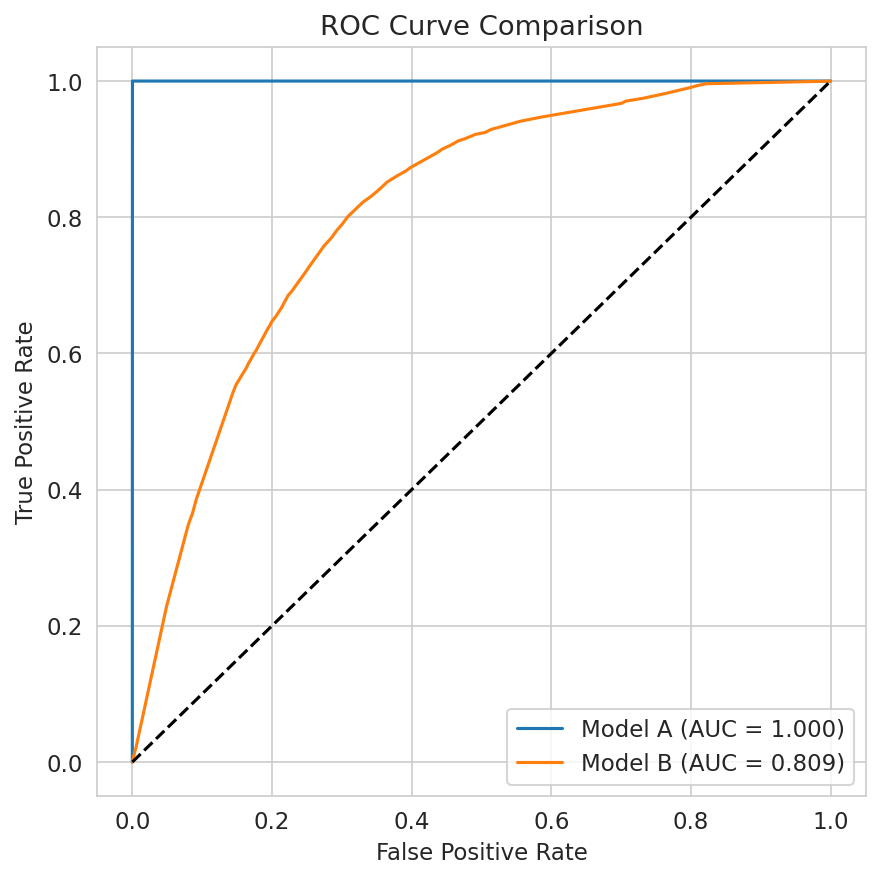

In [ ]:
# ROC curve comparison
fpr_A, tpr_A, _ = roc_curve(y_test, probs_A)
fpr_B, tpr_B, _ = roc_curve(y_test, probs_B)

auc_A = auc(fpr_A, tpr_A)
auc_B = auc(fpr_B, tpr_B)

plt.figure(figsize=(6,6))

plt.plot(fpr_A, tpr_A, label=f"Model A (AUC = {auc_A:.3f})")
plt.plot(fpr_B, tpr_B, label=f"Model B (AUC = {auc_B:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.tight_layout()
plt.savefig("ROC_Curve.png", dpi=600)
plt.show()

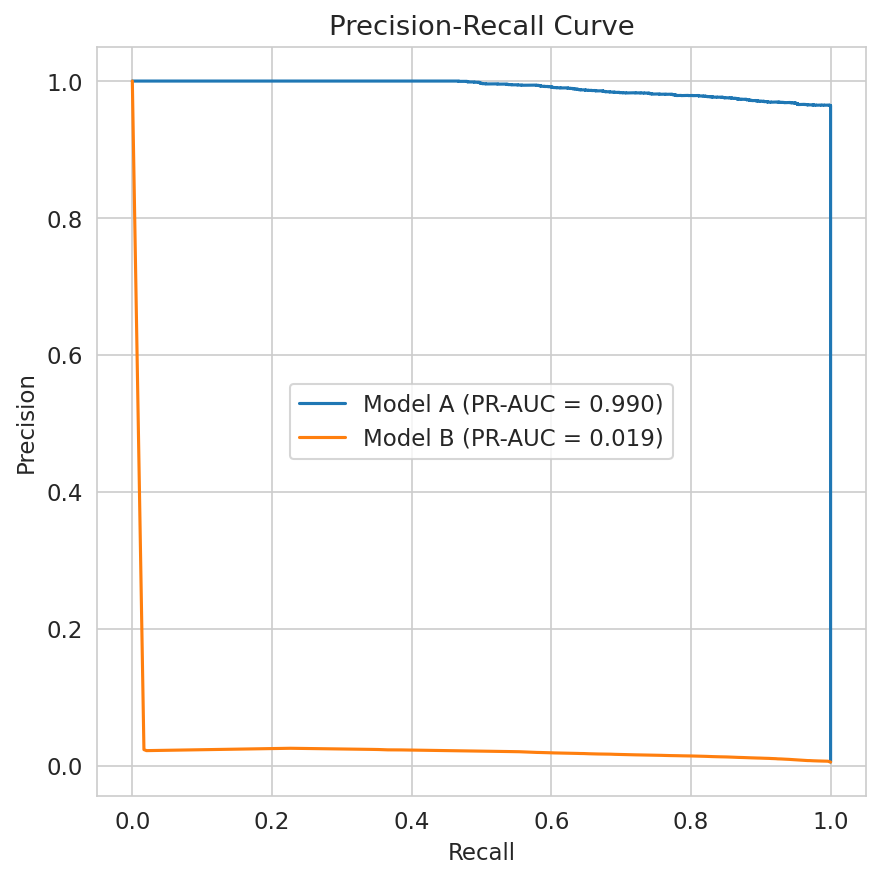

In [ ]:
# Precision recall curve
from sklearn.metrics import precision_recall_curve, average_precision_score

prec_A, rec_A, _ = precision_recall_curve(y_test, probs_A)
prec_B, rec_B, _ = precision_recall_curve(y_test, probs_B)

pr_auc_A = average_precision_score(y_test, probs_A)
pr_auc_B = average_precision_score(y_test, probs_B)

plt.figure(figsize=(6,6))

plt.plot(rec_A, prec_A, label=f"Model A (PR-AUC = {pr_auc_A:.3f})")
plt.plot(rec_B, prec_B, label=f"Model B (PR-AUC = {pr_auc_B:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.tight_layout()
plt.savefig("PR_Curve.png", dpi=600)
plt.show()

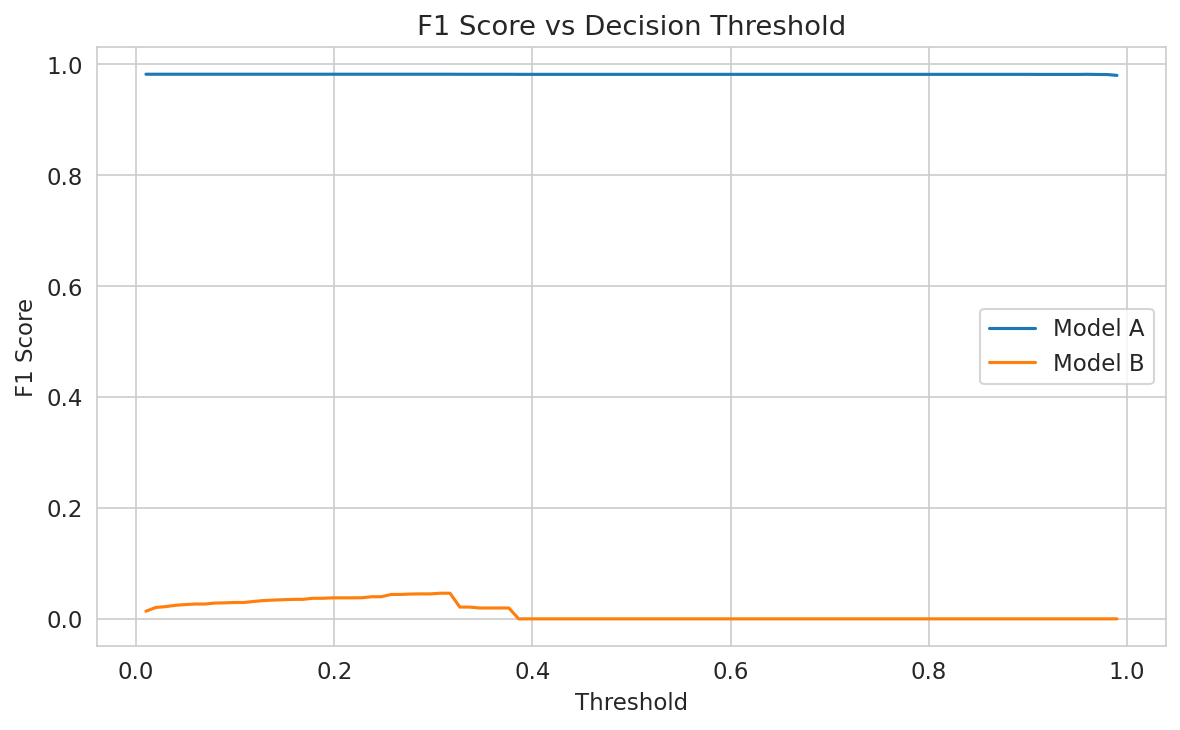

In [ ]:
# F1 score vs threshold

thresholds = np.linspace(0.01, 0.99, 100)

f1_A = []
f1_B = []

for t in thresholds:
    preds_A = (probs_A > t).astype(int)
    preds_B = (probs_B > t).astype(int)

    f1_A.append(f1_score(y_test, preds_A))
    f1_B.append(f1_score(y_test, preds_B))

plt.figure(figsize=(8,5))

plt.plot(thresholds, f1_A, label="Model A")
plt.plot(thresholds, f1_B, label="Model B")

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Decision Threshold")
plt.legend()

plt.tight_layout()
plt.savefig("F1_vs_Threshold.png", dpi=600)
plt.show()

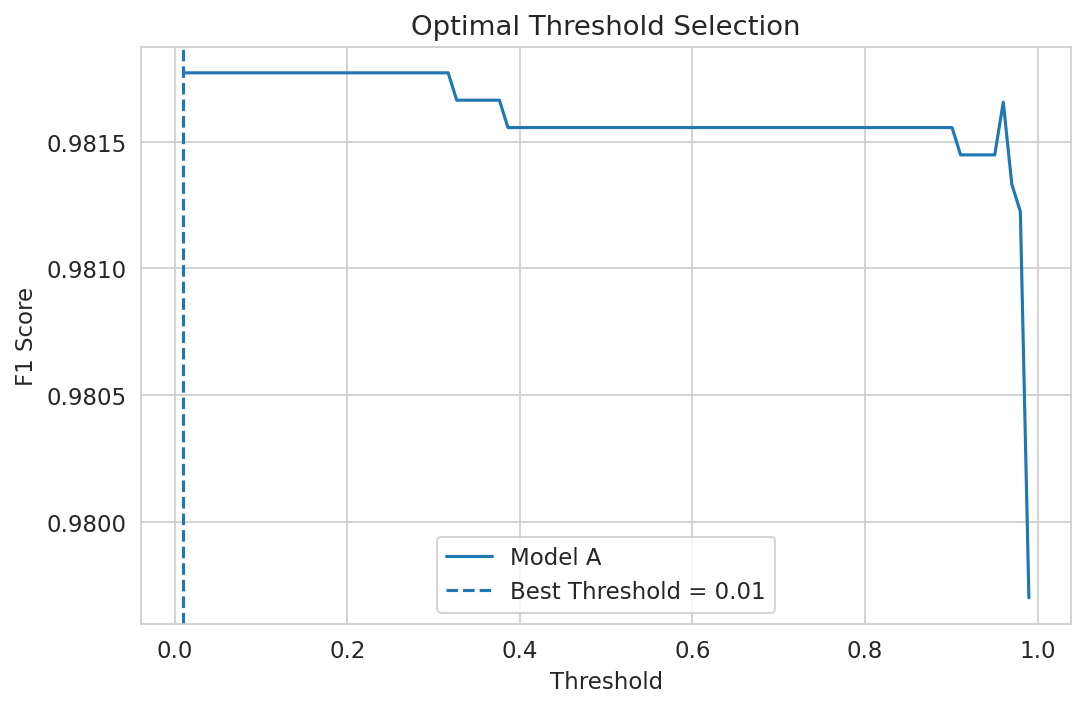

In [ ]:
best_idx = np.argmax(f1_A)
best_thresh = thresholds[best_idx]

plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_A, label="Model A")

plt.axvline(best_thresh, linestyle="--", label=f"Best Threshold = {best_thresh:.2f}")

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Optimal Threshold Selection")
plt.legend()

plt.savefig("Best_Threshold.png", dpi=600)
plt.show()

In [ ]:
#Figures
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


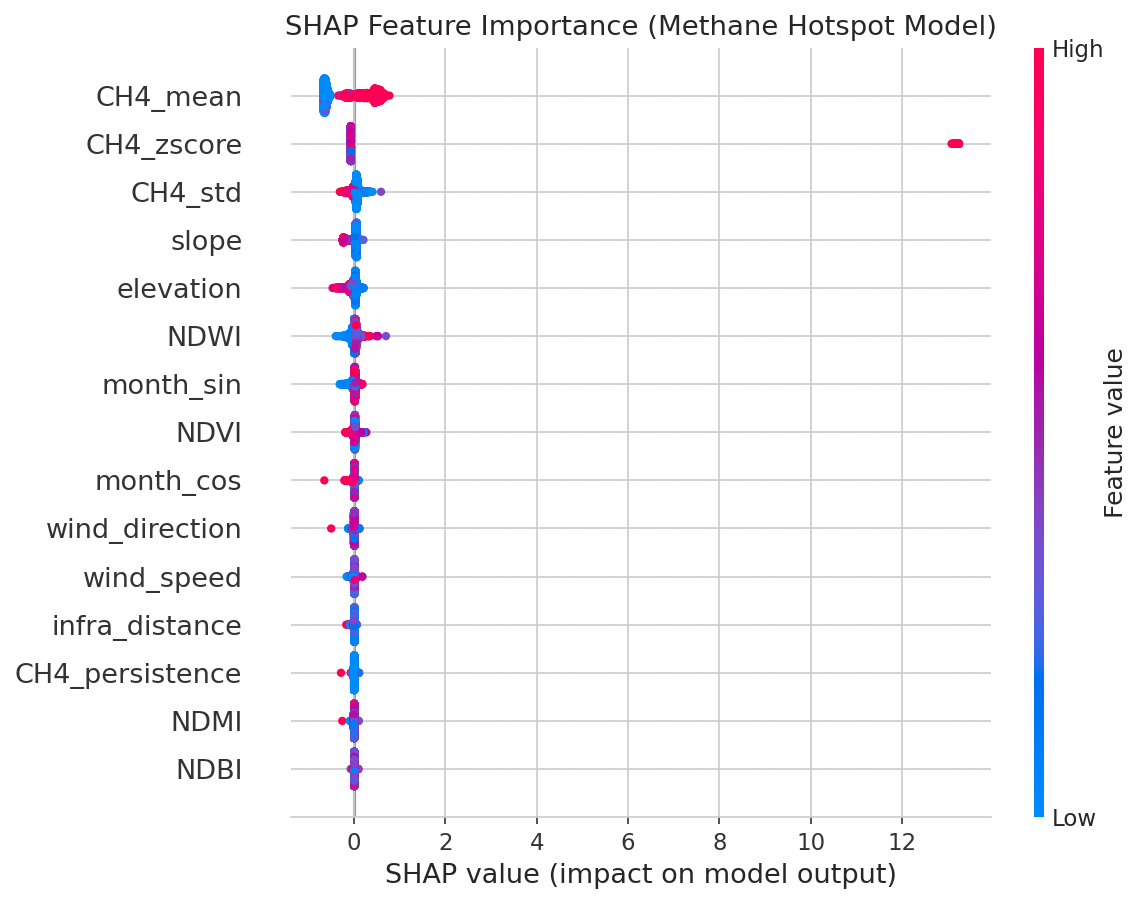

In [ ]:
# SHAP feature importance
import shap

# Sample for speed
X_sample = X_test_A.sample(5000, random_state=42)

explainer = shap.TreeExplainer(model_A)
shap_values = explainer.shap_values(X_sample)

plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    max_display=15,
    plot_size=(8,6),
    show=False
)

plt.title("SHAP Feature Importance (Methane Hotspot Model)")

# Save high-res
plt.savefig("SHAP_Feature_Importance.png", bbox_inches='tight', dpi=600)
plt.show()

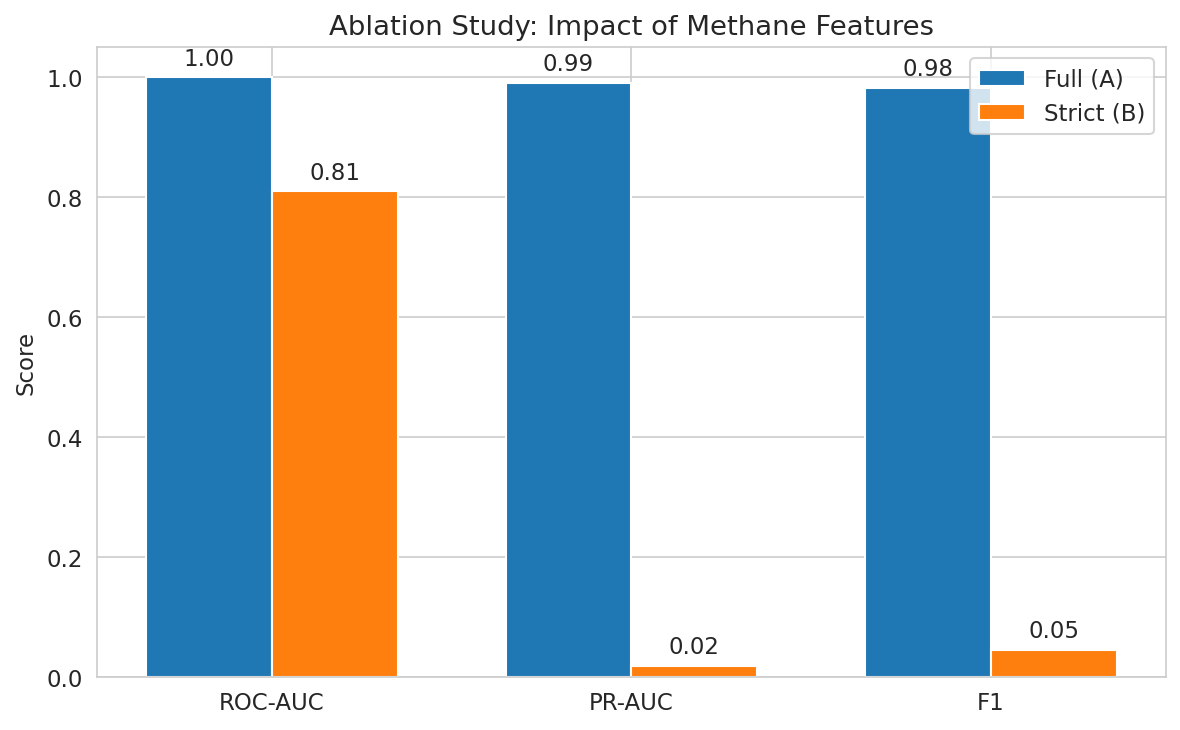

In [ ]:
# Ablation bar chart
results = pd.DataFrame({
    "Model": ["Full (A)", "Strict (B)"],
    "ROC-AUC": [0.99995, 0.80936],
    "PR-AUC": [0.99047, 0.01944],
    "F1": [0.98177, 0.04619]
})

metrics = ["ROC-AUC", "PR-AUC", "F1"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(x - width/2, results.iloc[0, 1:], width, label="Full (A)")
ax.bar(x + width/2, results.iloc[1, 1:], width, label="Strict (B)")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Ablation Study: Impact of Methane Features")

ax.legend()
ax.set_ylim(0, 1.05)

# Annotate values
for i, v in enumerate(results.iloc[0, 1:]):
    ax.text(i - width/2, v + 0.02, f"{v:.2f}", ha='center')

for i, v in enumerate(results.iloc[1, 1:]):
    ax.text(i + width/2, v + 0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.savefig("Ablation_Study.png", dpi=600)
plt.show()

In [ ]:
# Predictions
test_df["hotspot_prob"] = model_A.predict_proba(X_test_A)[:, 1]

# Hotspots
hotspots = test_df[test_df["hotspot_prob"] > 0.9].copy()

# DBSCAN-ready data (sample to avoid crash)
cluster_df = hotspots.sample(min(len(hotspots), 100000), random_state=42).copy()

# Add country
data["country"] = data["source_file"].apply(lambda x: x.split("/")[-1].split("_")[0])
test_df["country"] = test_df["source_file"].apply(lambda x: x.split("/")[-1].split("_")[0])

# Yearly trends
yearly = data.groupby(["year", "country"])["CH4_mean"].mean().reset_index()

# Monthly hotspot evolution
monthly = test_df.groupby(["year", "month"])["hotspot_prob"].mean().reset_index()
monthly["time"] = monthly["year"].astype(str) + "-" + monthly["month"].astype(str)

In [ ]:
# DBSCAN
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

coords = cluster_df[["lat", "lon"]]
prob = cluster_df[["hotspot_prob"]]

X_cluster = np.hstack([coords, prob])
X_scaled = StandardScaler().fit_transform(X_cluster)

db = DBSCAN(eps=0.3, min_samples=20).fit(X_scaled)

cluster_df["cluster"] = db.labels_

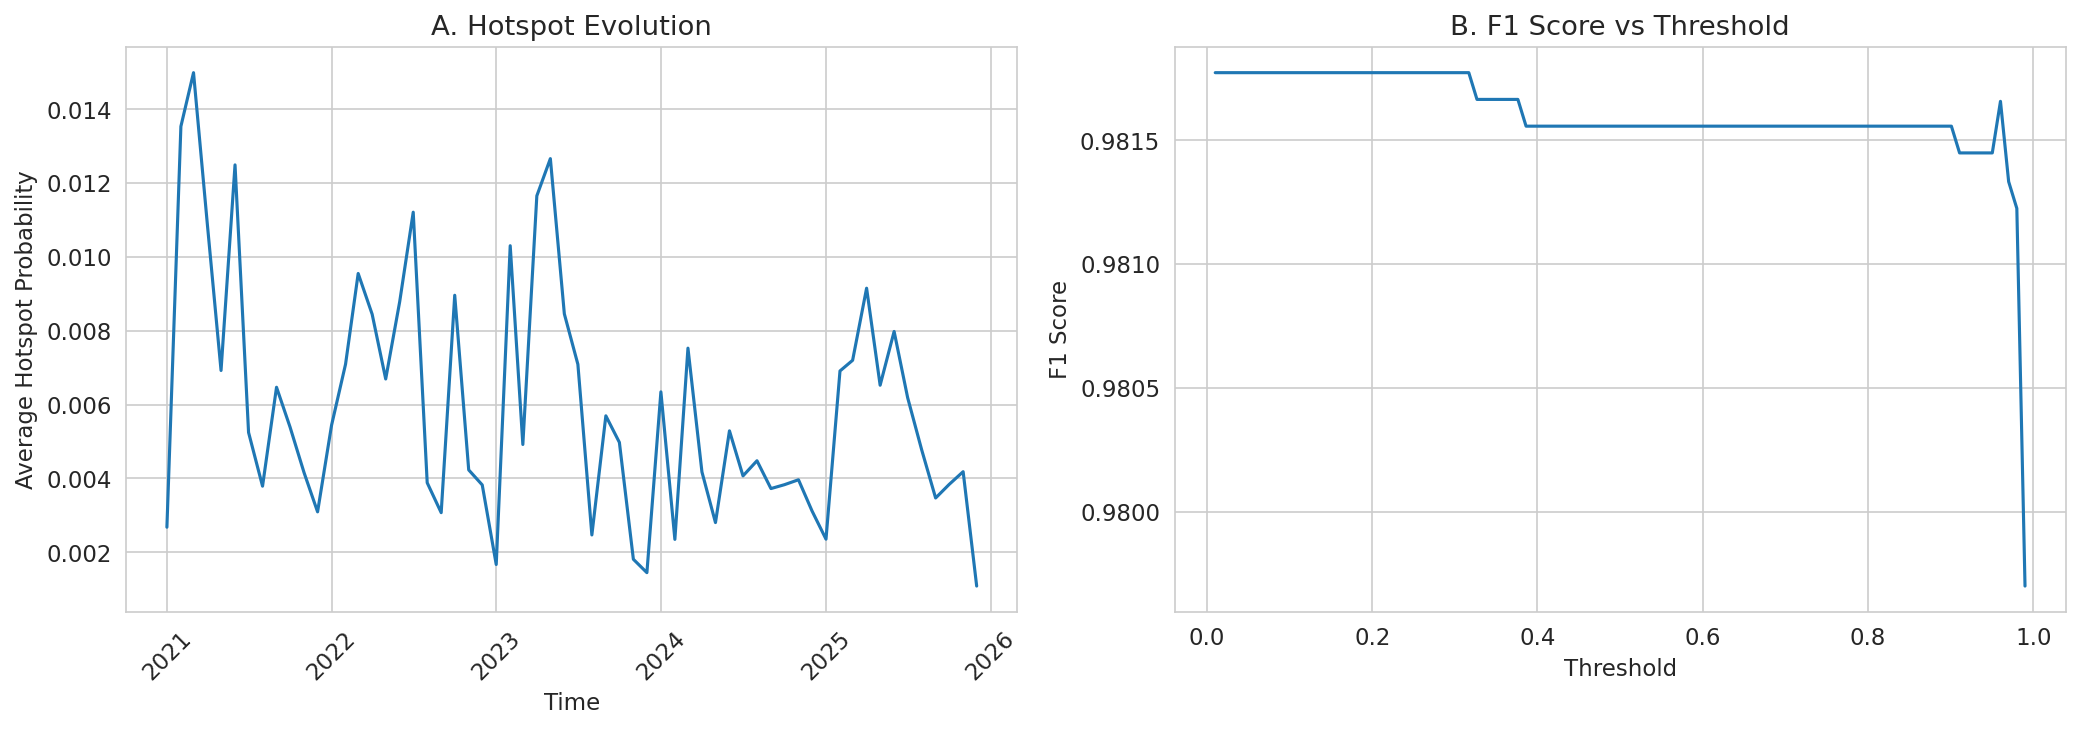

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# B. Temporal evolution (Hotspots)
axes[0].plot(monthly["date"], monthly["hotspot_prob"])
axes[0].set_title("A. Hotspot Evolution")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Average Hotspot Probability")

axes[0].tick_params(axis='x', rotation=45)

# Optional: reduce clutter on x-axis
axes[0].xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

# C. F1 vs Threshold
axes[1].plot(thresholds, f1_A)
axes[1].set_title("B. F1 Score vs Threshold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1 Score")

plt.tight_layout()
plt.savefig("Figure_4_Temporal.png", dpi=600)
plt.show()

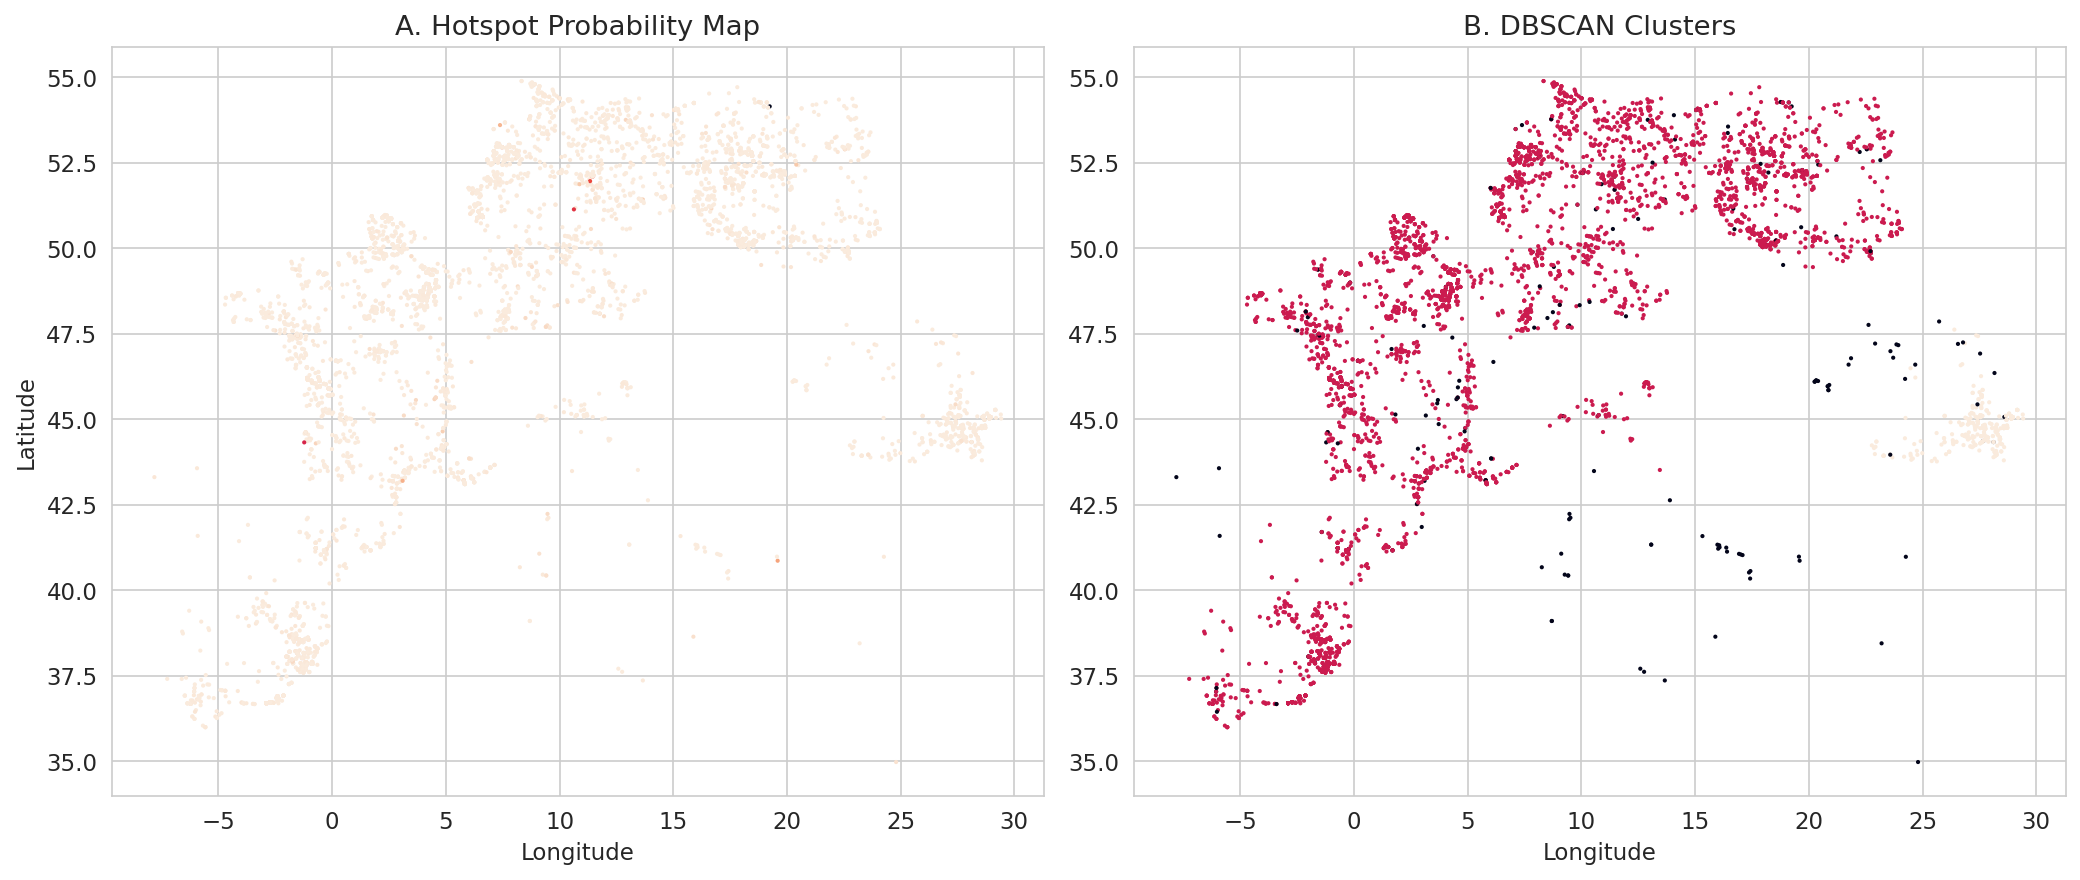

In [ ]:
# Spatial panel
fig = plt.figure(figsize=(14,6))

# A. Hotspot Map
plt.subplot(1,2,1)

if len(hotspots) > 0:
    sample_size = min(len(hotspots), 50000)
    sample_hotspots = hotspots.sample(sample_size)

    plt.scatter(
        sample_hotspots["lon"],
        sample_hotspots["lat"],
        c=sample_hotspots["hotspot_prob"],
        s=1
    )

plt.title("A. Hotspot Probability Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# B. Clusters
plt.subplot(1,2,2)

plt.scatter(
    cluster_df["lon"],
    cluster_df["lat"],
    c=cluster_df["cluster"],
    s=1
)

plt.title("B. DBSCAN Clusters")
plt.xlabel("Longitude")

plt.tight_layout()
plt.savefig("Spatial.png", dpi=600)
plt.show()

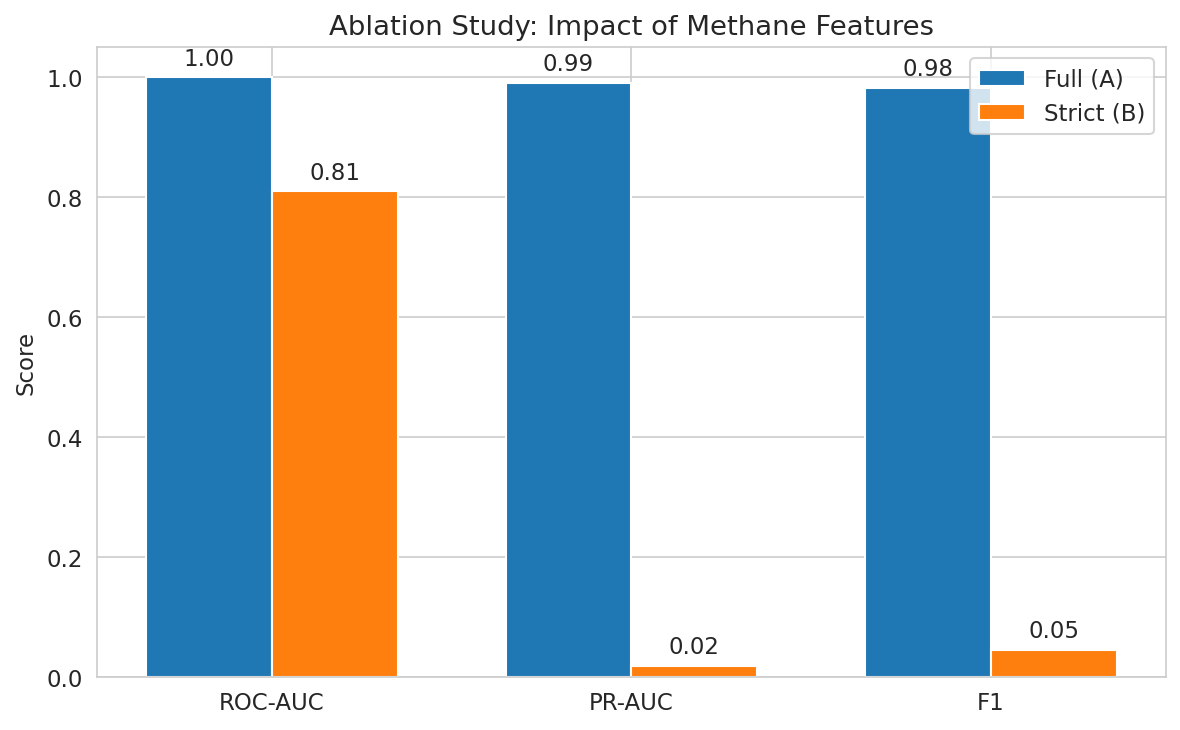

In [ ]:
# Ablation bar chart
results = pd.DataFrame({
    "Model": ["Full (A)", "Strict (B)"],
    "ROC-AUC": [0.99995, 0.80936],
    "PR-AUC": [0.99047, 0.01944],
    "F1": [0.98177, 0.04619]
})

metrics = ["ROC-AUC", "PR-AUC", "F1"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(x - width/2, results.iloc[0, 1:], width, label="Full (A)")
ax.bar(x + width/2, results.iloc[1, 1:], width, label="Strict (B)")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Ablation Study: Impact of Methane Features")

ax.legend()
ax.set_ylim(0, 1.05)

# Annotate values
for i, v in enumerate(results.iloc[0, 1:]):
    ax.text(i - width/2, v + 0.02, f"{v:.2f}", ha='center')

for i, v in enumerate(results.iloc[1, 1:]):
    ax.text(i + width/2, v + 0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.savefig("Ablation_Study.png", dpi=600)
plt.show()

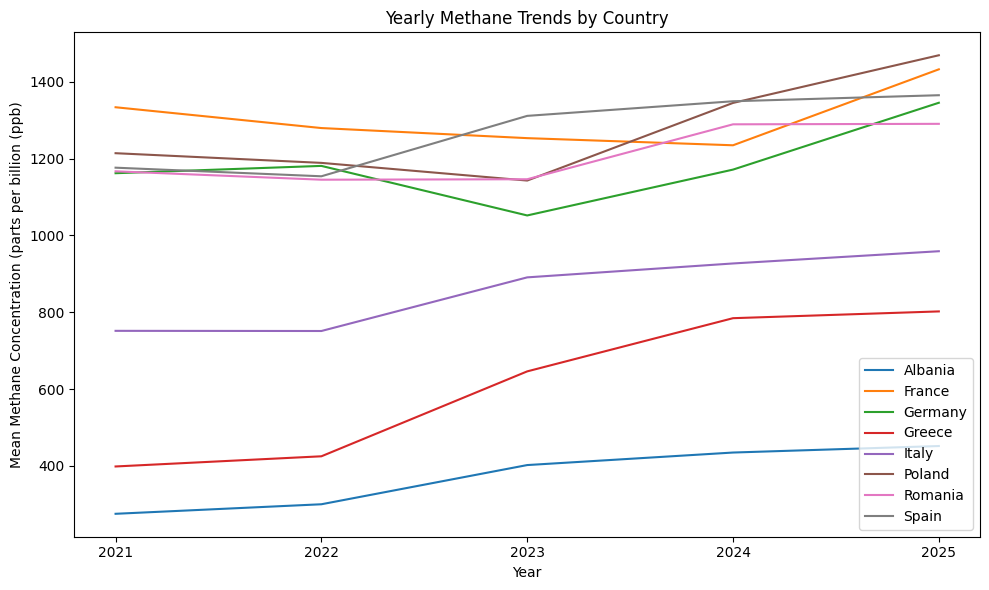

In [ ]:
# Ensure country exists
data["country"] = data["source_file"].apply(lambda x: x.split("/")[-1].split("_")[0])

# convert year to integer (important step)
data["year"] = data["year"].astype(int)

# Yearly trend
yearly = data.groupby(["year", "country"])["CH4_mean"].mean().reset_index()

plt.figure(figsize=(10,6))

for country in yearly["country"].unique():
    subset = yearly[yearly["country"] == country].sort_values("year")
    plt.plot(subset["year"], subset["CH4_mean"], label=country)

plt.xlabel("Year")
plt.ylabel("Mean Methane Concentration (parts per billion (ppb)")
plt.title("Yearly Methane Trends by Country")
plt.legend()

# Optional: force integer ticks (clean axis)
plt.xticks(yearly["year"].unique().astype(int))

plt.tight_layout()
plt.savefig("Yearly_Methane_Trends.png", dpi=600)
plt.show()

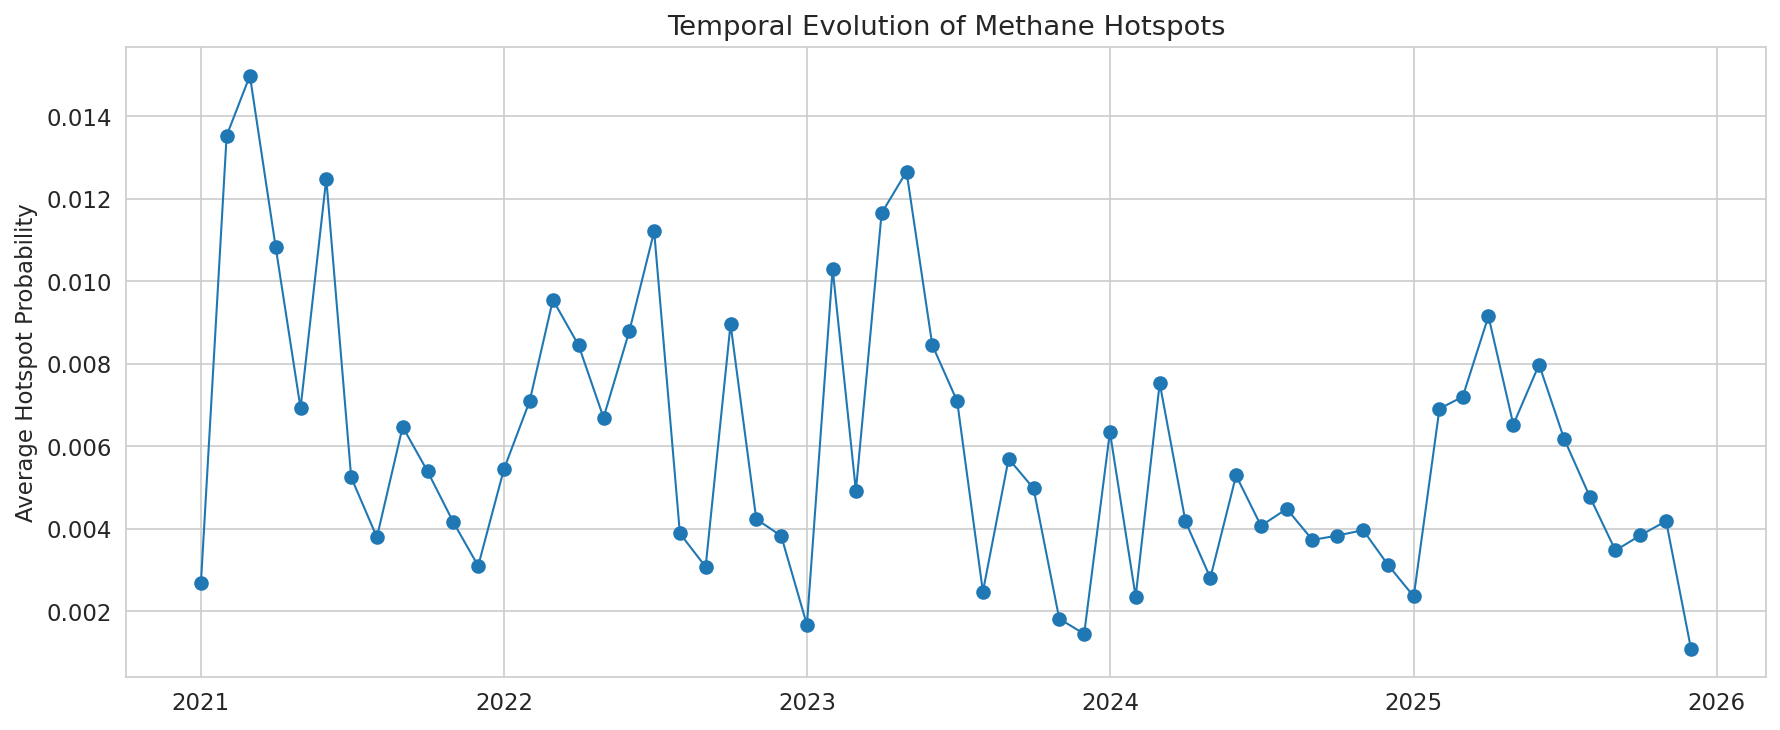

In [ ]:

# Aggregate
monthly = test_df.groupby(["year", "month"])["hotspot_prob"].mean().reset_index()

# Create proper datetime
monthly["date"] = pd.to_datetime(
    monthly["year"].astype(str) + "-" + monthly["month"].astype(str) + "-01"
)

monthly = monthly.sort_values("date")

plt.figure(figsize=(12,5))
plt.plot(monthly["date"], monthly["hotspot_prob"], marker="o", linewidth=1)

plt.ylabel("Average Hotspot Probability")
plt.title("Temporal Evolution of Methane Hotspots")

# Show fewer x-axis ticks (yearly instead of monthly)
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("Temporal_Hotspot_Evolution.png", dpi=600)
plt.show()

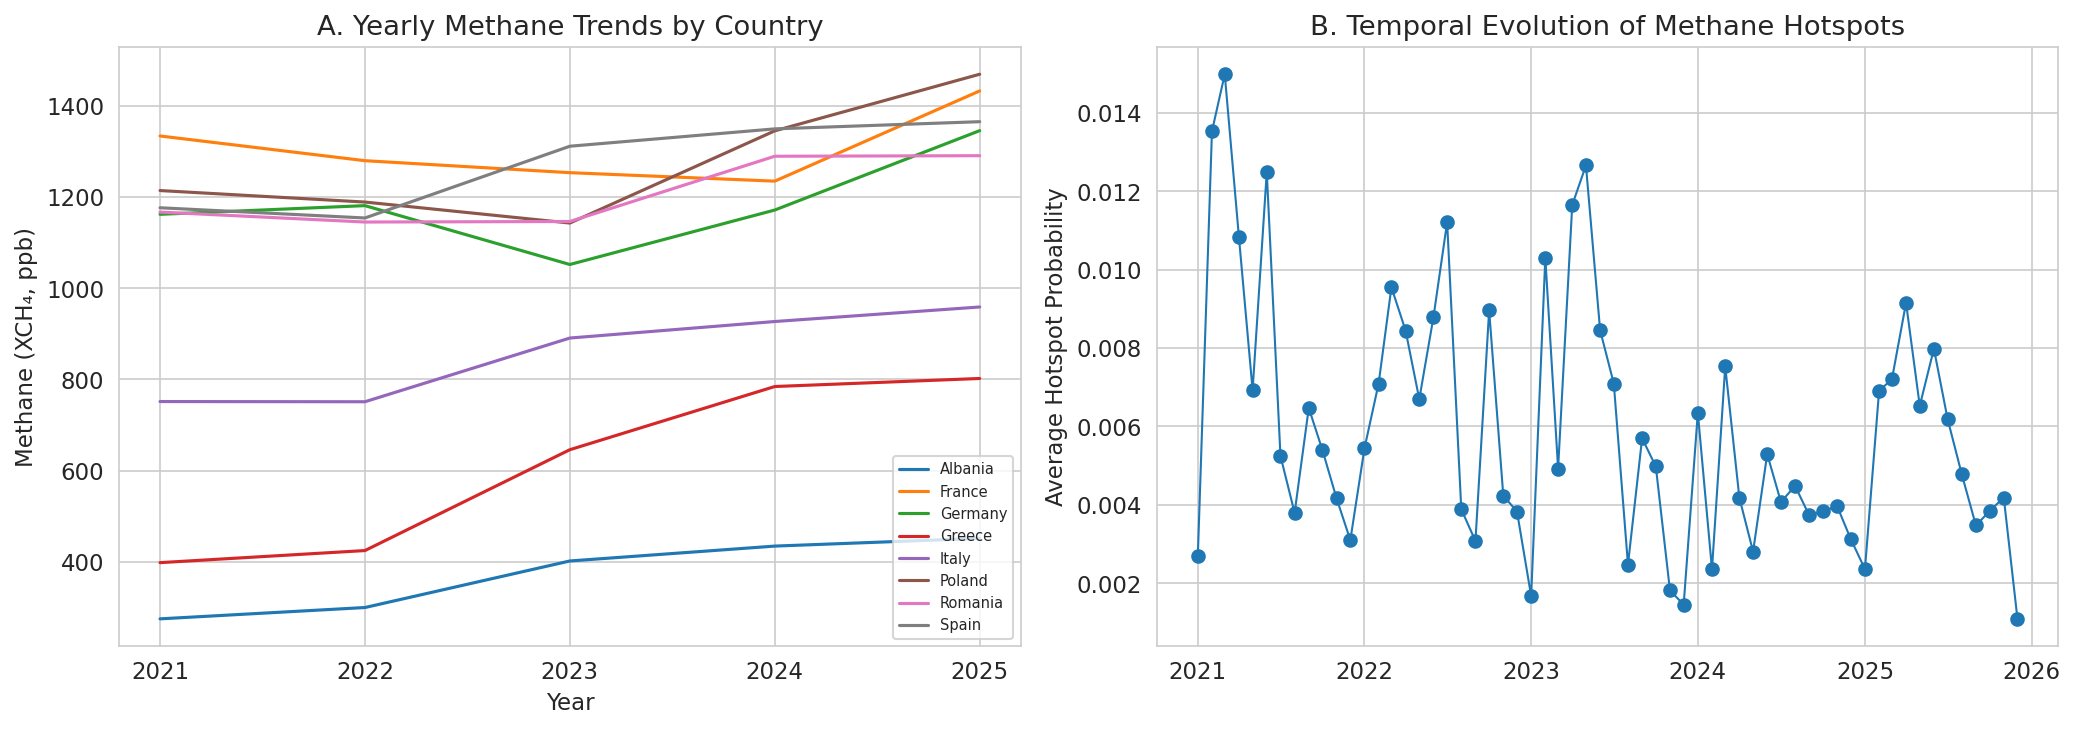

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -------------------------------
# Prepare data (safe)
# -------------------------------

# Country extraction
data["country"] = data["source_file"].apply(lambda x: x.split("/")[-1].split("_")[0])
data["year"] = data["year"].astype(int)

# Yearly aggregation
yearly = data.groupby(["year", "country"])["CH4_mean"].mean().reset_index()

# Monthly aggregation
monthly = test_df.groupby(["year", "month"])["hotspot_prob"].mean().reset_index()

monthly["date"] = pd.to_datetime(
    monthly["year"].astype(str) + "-" + monthly["month"].astype(str) + "-01"
)

monthly = monthly.sort_values("date")

# -------------------------------
# Plot (SIDE-BY-SIDE)
# -------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ===============================
# LEFT: Yearly Methane Trends
# ===============================
for country in yearly["country"].unique():
    subset = yearly[yearly["country"] == country].sort_values("year")
    axes[0].plot(subset["year"], subset["CH4_mean"], label=country)

axes[0].set_xlabel("Year")
axes[0].set_ylabel("Methane (XCH₄, ppb)")
axes[0].set_title("A. Yearly Methane Trends by Country")

# Clean integer ticks
axes[0].set_xticks(sorted(yearly["year"].unique()))
axes[0].legend(fontsize=7)

# ===============================
# RIGHT: Hotspot Evolution
# ===============================
axes[1].plot(
    monthly["date"],
    monthly["hotspot_prob"],
    marker="o",
    linewidth=1
)

axes[1].set_ylabel("Average Hotspot Probability")
axes[1].set_title("B. Temporal Evolution of Methane Hotspots")

# Clean time axis
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()

# Save high-resolution
plt.savefig("Figure_Temporal_Combined.png", dpi=600)

plt.show()